In [37]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
from tensorflow.keras.models import load_model
import os
import imghdr
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

In [9]:
# Prevent OOM errors by setting GPU memoory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [11]:
data_dir = 'C:/Users/sayan/.cache/kagglehub/datasets/kellysanderson/myopia-image-dataset/versions/1/IMAGES'

image_exts = ['jpeg', 'jpg', 'bmp', 'png', 'tiff', 'gif', 'webp']

In [13]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))

In [14]:
# LOAD DATA
data = image_dataset_from_directory(data_dir, batch_size=32, shuffle=True)

# Limit the dataset size for faster testing (approximately 100 images per class)
# Assuming 2 classes, this will give roughly 100 images per class
data = data.take(200)  # Adjust this number based on your number of classes

data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

Found 124794 files belonging to 2 classes.


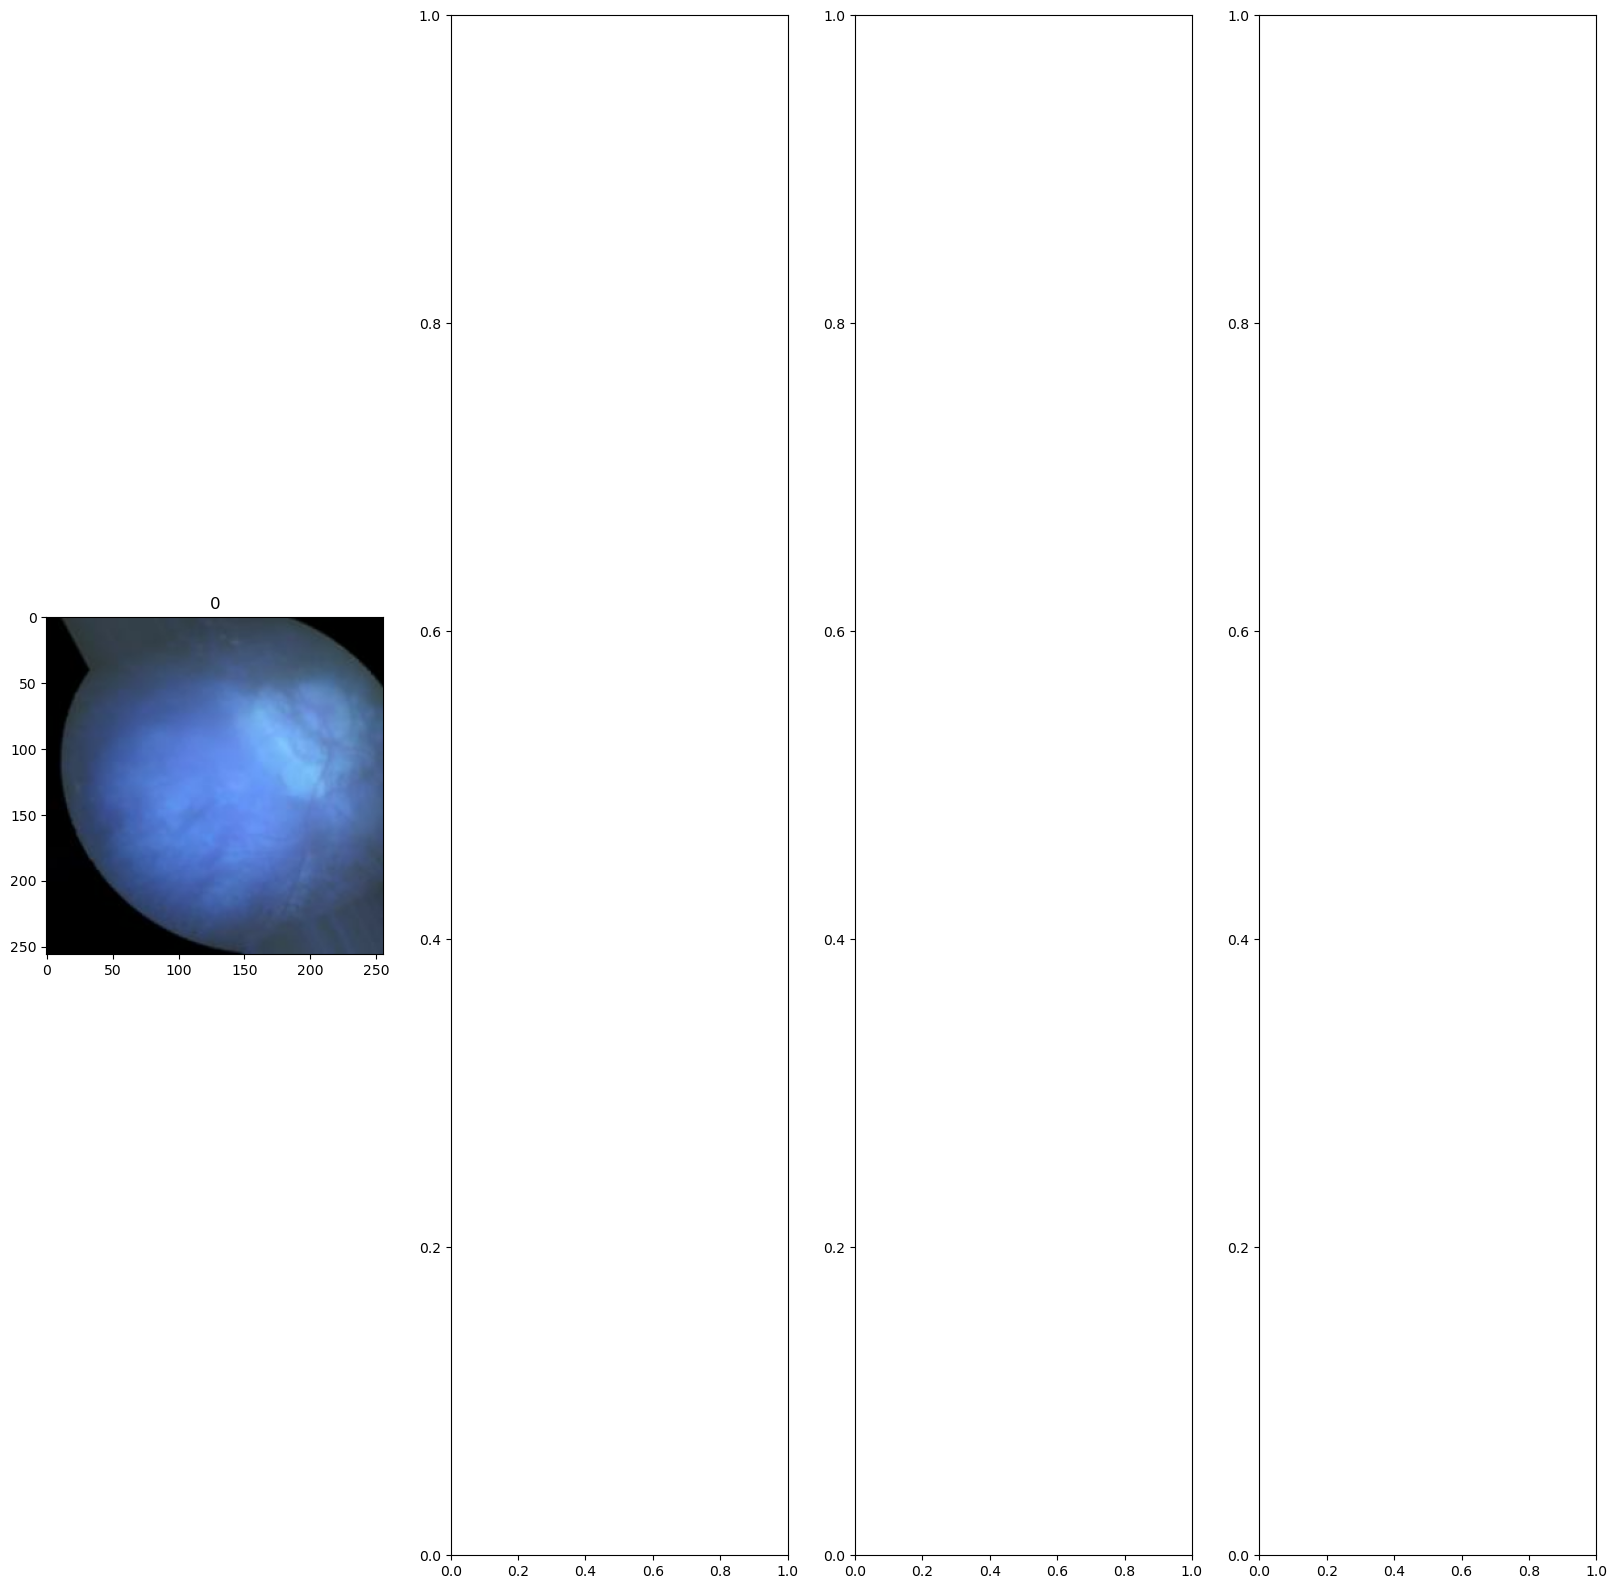

In [15]:
fig, ax = plt.subplots(ncols = 4, figsize = (20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])
    plt.show()

In [16]:
# PREPROCESS DATA
data = data.map(lambda x, y: (x/255, y))
scaled_iterator = data.as_numpy_iterator()
scaled_batch = scaled_iterator.next()

In [17]:
print("Data length: ", len(data))

Data length:  200


In [18]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

print("Train size: ", train_size)
print("Validation size: ", val_size)
print("Test size: ", test_size)

Train size:  140
Validation size:  40
Test size:  20


In [19]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [20]:
# MODEL BUILDING
model = Sequential()

model.add(Conv2D(16, (3, 3), 1, activation = 'relu', input_shape = (256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3, 3), 1, activation = 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3, 3), 1, activation = 'relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile('adam', loss = BinaryCrossentropy(), metrics = ['accuracy'])
print(model.summary())

C:\Users\sayan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
logdir = 'logs'
tensorboard_callback = TensorBoard(log_dir = logdir)
hist = model.fit(train, epochs = 20, validation_data = val, callbacks = [tensorboard_callback])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.8666 - loss: 0.2881 - val_accuracy: 0.9680 - val_loss: 0.0833
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.9688 - loss: 0.0848 - val_accuracy: 0.9719 - val_loss: 0.0807
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.9732 - loss: 0.0766 - val_accuracy: 0.9758 - val_loss: 0.0542
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.9787 - loss: 0.0504 - val_accuracy: 0.9617 - val_loss: 0.1017
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step - accuracy: 0.9802 - loss: 0.0514 - val_accuracy: 0.9758 - val_loss: 0.0617
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 199ms/step - accuracy: 0.9825 - loss: 0.0418 - val_accuracy: 0.9789 - val_loss: 0.0616
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.9886 - loss: 0.0340 - val_accuracy: 0.9766 - val_loss: 0.0669
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 204ms/step - accuracy: 0.9877 - loss: 0

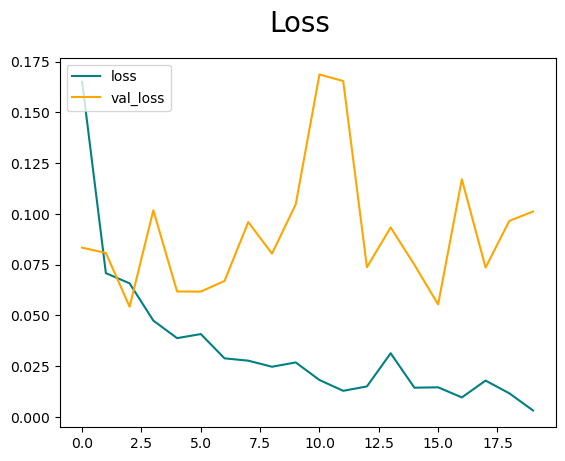

In [22]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'orange', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = 'upper left')
plt.show()

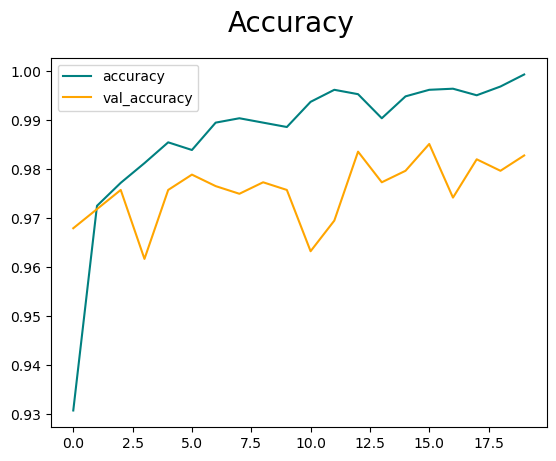

In [23]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 20)
plt.legend(loc = 'upper left')
plt.show()

In [24]:
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

In [29]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [31]:
print(f'Precision:{precision.result().numpy()}, Recall:{recall.result().numpy()}, Accuracy: {accuracy.result().numpy()}')

Precision:0.9792899489402771, Recall:0.9880596995353699, Accuracy: 0.9828125238418579


In [33]:
# SAVE MODEL
model.save(os.path.join('models', 'myopiadetectionmodel.h5'))

In [39]:
new_model = load_model(os.path.join('models', 'myopiadetectionmodel.h5'))

In [53]:
image_path = r"C:\Users\sayan\Downloads\myopiatest.jpeg"

# Step 1: Read the image file
image_raw = tf.io.read_file(image_path)

# Step 2: Decode the image (this will give you a tensor)
image_tensor = tf.image.decode_image(image_raw, channels=3)  # channels=3 to ensure RGB

# Step 3: Resize the image
resized_image = tf.image.resize(image_tensor, (256, 256))

In [55]:
yhatnew = new_model.predict(np.expand_dims(resized_image/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [57]:
if yhatnew > 0.5:
    print(f'Myopia Detected')
else:
    print(f'No Myopia')

No Myopia
